Submitted by Arnav Aditya. Roll no. - 2210110189

In [ ]:
!apt-get install -y git-lfs

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git-lfs is already the newest version (3.0.2-1ubuntu0.3).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


In [ ]:
import glob

In [ ]:
# Flickr8k from the Keras example / jbrownlee mirror (works in Colab / Linux)
!wget -q https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip
!wget -q https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip
!unzip -qq Flickr8k_Dataset.zip
!unzip -qq Flickr8k_text.zip
!rm Flickr8k_Dataset.zip Flickr8k_text.zip

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import os
import re
import json
import random
from collections import Counter
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

# For evaluation:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score

In [ ]:
# ------------- Hyperparams (tweakable by students) -------------
EMBED_SIZE = 256        # word embedding dim
HIDDEN_SIZE = 512       # RNN hidden state dim
NUM_LAYERS = 1
BATCH_SIZE = 64
LR = 1e-3
EPOCHS = 5              # keep small for lab/demo
MAX_SEQ_LEN = 20
MIN_WORD_FREQ = 5       # min freq to keep in vocab
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [ ]:
# ------------ Simple Vocabulary builder -------------
class Vocabulary:
    def __init__(self, freq_threshold=MIN_WORD_FREQ):
        self.freq_threshold = freq_threshold
        self.word2idx = {"<pad>":0, "<start>":1, "<end>":2, "<unk>":3}
        self.idx2word = {0:"<pad>", 1:"<start>", 2:"<end>", 3:"<unk>"}
        self.freqs = Counter()
        self.next_idx = 4

    def tokenize(self, text):
        text = text.lower()
        # simple tokenization; students can replace with better tokenizer
        tokens = re.findall(r"\w+", text)
        # tokens = [tok for tok in nltk.word_tokenize(text) if tok.isalpha()]

        return tokens


    def build_vocab(self, captions_list):
        for caption in captions_list:
            tokens = self.tokenize(caption)
            self.freqs.update(tokens)
        for word, cnt in self.freqs.items():
            if cnt >= self.freq_threshold:
                self.word2idx[word] = self.next_idx
                self.idx2word[self.next_idx] = word
                self.next_idx += 1

    def numericalize(self, text):
        tokens = self.tokenize(text)
        return [self.word2idx.get(tok, self.word2idx["<unk>"]) for tok in tokens]

In [ ]:
# ------------ Dataset for Flickr8k (simple) -------------
from PIL import Image, UnidentifiedImageError

class FlickrDataset(Dataset):
    def __init__(self, images_dir, captions_file, vocab, transform=None, max_len=MAX_SEQ_LEN):
        self.images_dir = images_dir
        self.captions_file = captions_file
        self.vocab = vocab
        self.transform = transform
        self.max_len = max_len

        if not os.path.exists(self.images_dir):
            raise FileNotFoundError(f"Images directory not found: {self.images_dir}")
        if not os.path.exists(self.captions_file):
            raise FileNotFoundError(f"Captions file not found: {self.captions_file}")

        self.img_caps = {}
        with open(self.captions_file, "r", encoding="utf-8") as fh:
            for line in fh:
                line = line.strip()
                if not line:
                    continue
                parts = line.split("\t")
                if len(parts) != 2:
                    continue
                img_id, caption = parts
                img_id = img_id.split("#")[0]
                self.img_caps.setdefault(img_id, []).append(caption)
        if not self.img_caps:
            raise RuntimeError("No captions parsed from file.")

        candidate_ids = sorted(self.img_caps.keys())
        self.image_ids = []
        for imgname in candidate_ids:
            resolved = self._resolve_image_path(imgname)
            if resolved is None:
                continue
            if self._is_image_valid(resolved):
                self.image_ids.append(imgname)
            else:
                print(f"Skipping corrupted image: {imgname}")
        if not self.image_ids:
            raise RuntimeError("No valid images found in dataset.")

    @staticmethod
    def _is_image_valid(img_path):
        try:
            with Image.open(img_path) as img:
                img.verify()
            return True
        except (UnidentifiedImageError, OSError):
            return False

    def _resolve_image_path(self, imgname):
        imgpath = os.path.join(self.images_dir, imgname)
        if os.path.exists(imgpath):
            return imgpath
        base, _ = os.path.splitext(imgname)
        fallback = base + ".jpg"
        candidates = [
            os.path.join(self.images_dir, fallback),
            *glob.glob(os.path.join(self.images_dir, base + ".*"))
        ]
        for cand in candidates:
            if os.path.exists(cand):
                return cand
        return None

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        imgname = self.image_ids[idx]
        imgpath = self._resolve_image_path(imgname)
        if imgpath is None or not os.path.exists(imgpath):
            raise FileNotFoundError(f"{imgname} not found in {self.images_dir}")

        try:
            img = Image.open(imgpath).convert("RGB")
        except (UnidentifiedImageError, OSError) as exc:
            raise FileNotFoundError(f"{imgname} is corrupted") from exc

        img_t = self.transform(img) if self.transform else T.ToTensor()(img)

        captions = self.img_caps[imgname]
        caption = random.choice(captions)
        tokens = [self.vocab.word2idx["<start>"]] + self.vocab.numericalize(caption) + [self.vocab.word2idx["<end>"]]
        if len(tokens) > self.max_len:
            tokens = tokens[:self.max_len]
            tokens[-1] = self.vocab.word2idx["<end>"]
        caption_tensor = torch.tensor(tokens, dtype=torch.long)
        return img_t, caption_tensor, imgname

# Collate to pad sequences in a batch
def collate_fn(batch):
    imgs, caps, names = zip(*batch)
    imgs = torch.stack(imgs)
    lengths = [len(c) for c in caps]
    max_len = max(lengths)
    padded = torch.zeros(len(caps), max_len, dtype=torch.long)
    for i, cap in enumerate(caps):
        padded[i, :len(cap)] = cap
    return imgs, padded, lengths, names

In [ ]:
# ------------ Dataset for Flickr8k (simple) -------------
class FlickrDataset(Dataset):
    def __init__(self, images_dir, captions_file, vocab, transform=None, max_len=MAX_SEQ_LEN):
        """
        captions_file expected format: the Flickr8k_text files:
        - "Flickr8k.token.txt" contains lines: <image_name>#<cap_id>\t<caption>
        """
        self.images_dir = images_dir
        self.vocab = vocab
        self.transform = transform
        self.max_len = max_len

        # load captions
        self.img_caps = {}  # image -> list of captions
        with open(captions_file, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line: continue
                parts = line.split('\t')
                if len(parts) != 2: continue
                key, cap = parts
                raw_name = key.split('#')[0]
                if '.jpg' in raw_name:
                    clean_name = raw_name.split('.jpg')[0] + '.jpg'
                else:
                    clean_name = raw_name
                self.img_caps.setdefault(clean_name, []).append(cap)

        self.image_ids = sorted(list(self.img_caps.keys()))

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        imgname = self.image_ids[idx]
        imgpath = os.path.join(self.images_dir, imgname)
        if not os.path.exists(imgpath):
            base, _ = os.path.splitext(imgname)
            # direct .jpg retry
            fallback = base + ".jpg"
            alt_candidates = [
                os.path.join(self.images_dir, fallback),
                *glob.glob(os.path.join(self.images_dir, base + ".*"))
            ]
            for cand in alt_candidates:
                if os.path.exists(cand):
                    imgpath = cand
                    break
            else:
                raise FileNotFoundError(f"{imgname} not found in {self.images_dir}")
        img = Image.open(imgpath).convert('RGB')
        if self.transform:
            img_t = self.transform(img)
        else:
            img_t = T.ToTensor()(img)

        # pick one caption randomly (for training) and convert to tensor indices
        captions = self.img_caps[imgname]
        caption = random.choice(captions)
        # include start & end tokens
        tokens = [self.vocab.word2idx["<start>"]] + self.vocab.numericalize(caption) + [self.vocab.word2idx["<end>"]]
        if len(tokens) > self.max_len:
            tokens = tokens[:self.max_len]
            tokens[-1] = self.vocab.word2idx["<end>"]
        caption_tensor = torch.tensor(tokens, dtype=torch.long)
        return img_t, caption_tensor, imgname

# Collate to pad sequences in a batch
def collate_fn(batch):
    imgs, caps, names = zip(*batch)
    imgs = torch.stack(imgs)
    lengths = [len(c) for c in caps]
    max_len = max(lengths)
    padded = torch.zeros(len(caps), max_len, dtype=torch.long)
    for i, cap in enumerate(caps):
        padded[i, :len(cap)] = cap
    return imgs, padded, lengths, names

In [ ]:
# ------------- Simple CNN encoder (small) -------------
class SmallCNNEncoder(nn.Module):
    def __init__(self, embed_size=EMBED_SIZE):
        super().__init__()
        # Very small conv net for demonstrative purposes
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),  # 3 -> 32
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )
        self.fc = nn.Linear(64, embed_size)

    def forward(self, images):
        x = self.features(images)         # (B, 64, 1, 1)
        x = x.view(x.size(0), -1)         # (B, 64)
        x = self.fc(x)                    # (B, embed_size)
        return x


In [ ]:
# ------------- ResNet50 encoder with frozen backbone -------------
class ResNet50Encoder(nn.Module):
    def __init__(self, embed_size=EMBED_SIZE, pretrained=True):
        super().__init__()
        try:
            weights = models.ResNet50_Weights.DEFAULT if pretrained else None
            backbone = models.resnet50(weights=weights)
        except AttributeError:
            backbone = models.resnet50(pretrained=pretrained)
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])
        for param in self.feature_extractor.parameters():
            param.requires_grad = False
        self.fc = nn.Linear(backbone.fc.in_features, embed_size)
        nn.init.xavier_uniform_(self.fc.weight)
        nn.init.zeros_(self.fc.bias)

    def forward(self, images):
        feats = self.feature_extractor(images)
        feats = feats.view(feats.size(0), -1)
        embeds = self.fc(feats)
        return embeds

In [ ]:
# ------------- Decoder: simple vanilla RNN decoder -------------
class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        # vanilla RNN cell
        self.rnn = nn.RNN(embed_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

        # map image embedding to initial hidden
        self.img2hid = nn.Linear(embed_size, hidden_size)

    def forward(self, img_feats, captions, lengths):
        """
        img_feats: (B, embed_size)
        captions: (B, seq_len) with <start> ... <end> tokens
        lengths: list of lengths
        """
        embeddings = self.embed(captions)  # (B, seq_len, embed_size)
        # prepend image feature as time step 0 (or use as hidden init)
        h0 = torch.tanh(self.img2hid(img_feats)).unsqueeze(0)  # (num_layers, B, H)
        outputs, _ = self.rnn(embeddings, h0)   # (B, seq_len, H)
        outputs = self.fc(outputs)              # (B, seq_len, vocab)
        return outputs

    def sample(self, img_feats, vocab, max_len=MAX_SEQ_LEN):
        """Greedy sampling for demo/test"""
        self.eval()
        with torch.no_grad():
            hidden = torch.tanh(self.img2hid(img_feats)).unsqueeze(0)  # (1, B, H)
            inputs = torch.tensor([vocab.word2idx["<start>"]]*img_feats.size(0), device=img_feats.device).unsqueeze(1)  # (B,1)
            captions = []
            for _ in range(max_len):
                emb = self.embed(inputs)  # (B,1,embed)
                out, hidden = self.rnn(emb, hidden)  # out (B,1,H)
                out = self.fc(out.squeeze(1))  # (B, vocab)
                _, predicted = out.max(1)      # (B,)
                captions.append(predicted.unsqueeze(1))
                inputs = predicted.unsqueeze(1)
            captions = torch.cat(captions, dim=1)  # (B, max_len)
        return captions  # indices

In [ ]:
# ------------- Utility helpers -------------
def idxs_to_sentence(idxs, vocab):
    words = []
    for idx in idxs:
        w = vocab.idx2word.get(int(idx), "<unk>")
        if w == "<end>":
            break
        if w not in ("<start>", "<pad>"):
            words.append(w)
    return " ".join(words)

def visualize_prediction(img_path, pred_sentence, title=None):
    img = Image.open(img_path).convert('RGB')
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(title if title else pred_sentence)
    plt.show()


In [ ]:
# ------------- Training / simple demo loop (mini) -------------
def train_demo(images_dir, captions_txt):
    # 1) Build vocab
    # gather all captions quickly
    caps = []
    with open(captions_txt, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line: continue
            parts = line.split('\t')
            if len(parts) != 2: continue
            caps.append(parts[1])
    vocab = Vocabulary(freq_threshold=MIN_WORD_FREQ)
    vocab.build_vocab(caps)
    print("Vocab size:", len(vocab.word2idx))

    # transforms
    transform = T.Compose([
        T.Resize((224,224)),
        T.ToTensor(),
        T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
    ])
    dataset = FlickrDataset(images_dir, captions_txt, vocab, transform=transform)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

    # encoder and decoder (choose simple CNN + RNN)
    encoder = SmallCNNEncoder(EMBED_SIZE).to(DEVICE)
    decoder = DecoderRNN(EMBED_SIZE, HIDDEN_SIZE, len(vocab.word2idx), NUM_LAYERS).to(DEVICE)

    criterion = nn.CrossEntropyLoss(ignore_index=vocab.word2idx["<pad>"])
    params = list(encoder.parameters()) + list(decoder.parameters())
    optimizer = optim.Adam(params, lr=LR)

    # tiny training loop (teacher forcing)
    for epoch in range(EPOCHS):
        encoder.train(); decoder.train()
        total_loss = 0
        for imgs, caps, lengths, _ in tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
            imgs = imgs.to(DEVICE)
            caps = caps.to(DEVICE)
            # forward
            img_feats = encoder(imgs)   # (B, embed)
            outputs = decoder(img_feats, caps[:, :-1], lengths)  # predict next word at each time step
            # outputs (B, seq_len-1, V)
            targets = caps[:, 1:]  # shift
            outputs = outputs.view(-1, outputs.size(2))
            targets = targets.contiguous().view(-1)
            loss = criterion(outputs, targets)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1} loss: {total_loss/len(dataloader):.4f}")

    # Save demo models
    torch.save({'encoder': encoder.state_dict(), 'decoder': decoder.state_dict(), 'vocab': vocab.word2idx}, 'demo_model.pth')
    print("Saved demo_model.pth")

    # Quick evaluation on a handful of images (greedy)
    encoder.eval(); decoder.eval()
    sample_loader = DataLoader(dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
    imgs, caps, lengths, names = next(iter(sample_loader))
    imgs = imgs.to(DEVICE)
    with torch.no_grad():
        feats = encoder(imgs)
        sampled = decoder.sample(feats, vocab)  # (B, max_len)
    sampled = sampled.cpu().numpy()
    for i in range(min(8, sampled.shape[0])):
        pred = idxs_to_sentence(sampled[i], vocab)
        imgpath = os.path.join(images_dir, names[i])
        print("Pred:", pred)
        visualize_prediction(imgpath, pred)

    # Compute BLEU & METEOR on small subset (demo)
    refs_all = []
    hyps_all = []
    for i in range(10):  # small subset
        imgs, caps, lengths, names = next(iter(sample_loader))
        imgs = imgs.to(DEVICE)
        feats = encoder(imgs)
        sampled = decoder.sample(feats, vocab).cpu().numpy()
        for j in range(sampled.shape[0]):
            pred = idxs_to_sentence(sampled[j], vocab)
            hyps_all.append(pred.split())
            # get references (multiple captions)
            refs = []
            # dataset.img_caps accessible
            ref_caps = dataset.img_caps[names[j]]
            for r in ref_caps:
                refs.append(nltk.word_tokenize(r.lower()))
            refs_all.append(refs)


    if not hyps_all:
        print("No hypotheses generated; skipping BLEU/METEOR computation.")
        return

    # BLEU scores (corpus-level approximated by averaging sentence BLEU here)
    smooth = SmoothingFunction().method1
    bleu1 = np.mean([sentence_bleu(refs_all[i], hyps_all[i], weights=(1,0,0,0), smoothing_function=smooth) for i in range(len(hyps_all))])
    bleu4 = np.mean([sentence_bleu(refs_all[i], hyps_all[i], weights=(0.25,0.25,0.25,0.25), smoothing_function=smooth) for i in range(len(hyps_all))])
    meteor = np.mean([meteor_score(refs_all[i], hyps_all[i]) for i in range(len(hyps_all))])
    print(f"Demo BLEU-1: {bleu1:.4f}, BLEU-4: {bleu4:.4f}, METEOR: {meteor:.4f}")

Vocab size: 2982


Epoch 1/5: 100%|██████████| 127/127 [00:49<00:00,  2.55it/s]


Epoch 1 loss: 4.4558


Epoch 2/5: 100%|██████████| 127/127 [00:49<00:00,  2.55it/s]


Epoch 2 loss: 3.6950


...

Epoch 3 loss: 3.4700


Epoch 4/5: 100%|██████████| 127/127 [00:50<00:00,  2.53it/s]


Epoch 4 loss: 3.3233


Epoch 5/5: 100%|██████████| 127/127 [00:50<00:00,  2.53it/s]


Epoch 5 loss: 3.2272
Saved demo_model.pth
Pred: a man and a woman are standing on a bench


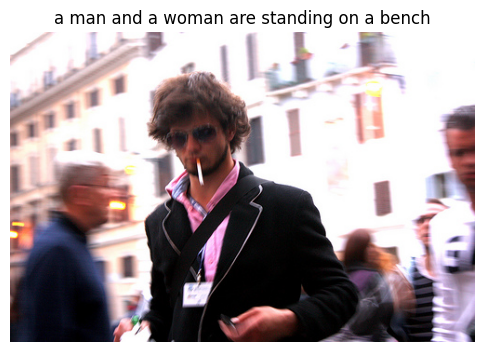

Pred: a man and a woman are standing on a bench with a <unk>


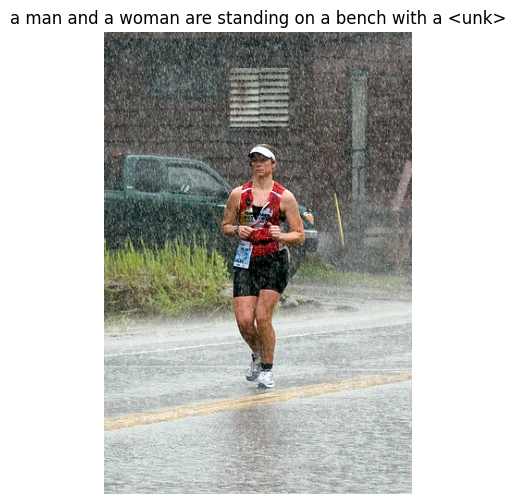

Pred: a man and a woman are standing on a bench


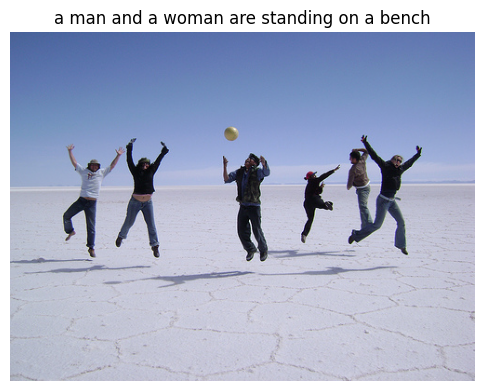

Pred: a dog runs through the water


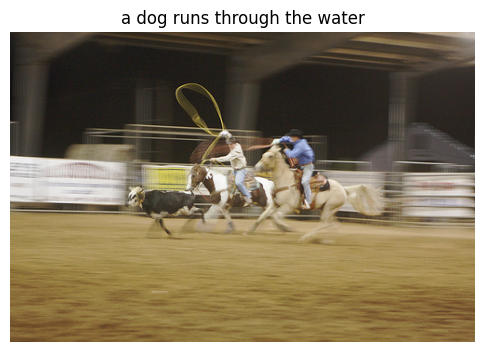

Pred: a man and a woman are standing on a bench


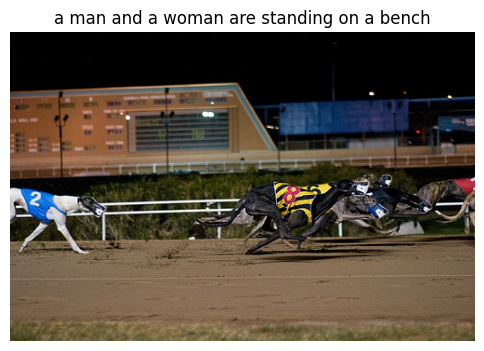

Pred: a man and a woman are standing on a bench


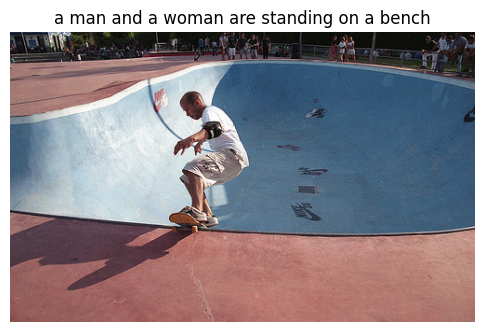

Pred: a man and a woman are standing on a bench


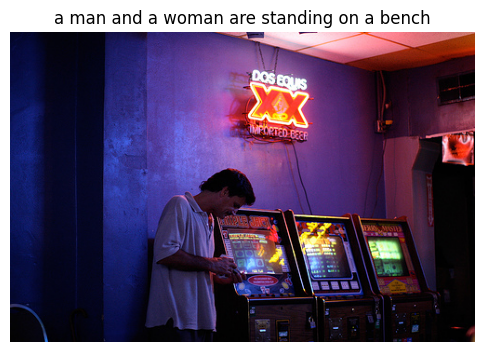

Pred: a man and a woman are standing on a bench


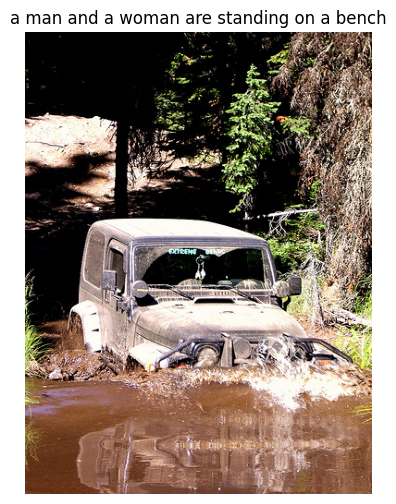

Demo BLEU-1: 0.4250, BLEU-4: 0.0585, METEOR: 0.2420


In [ ]:
 # Update these paths to where you unzipped Flickr8k_Dataset and the text file
IMAGES_DIR = "/content/Flicker8k_Dataset"
CAPTIONS_FILE = "Flickr8k.token.txt"
# Ensure NLTK data present
train_demo(IMAGES_DIR, CAPTIONS_FILE)

#Question (10 marks total). You have the boilerplate image-captioning code provided in the lab (Flickr8k, PyTorch). Perform the tasks below and submit: (i) modified code files or diff, results and answers. Label your answers (a)–(d).

##(a) Replace the vanilla RNN decoder with an LSTM decoder and run a short training (3 epochs). (3 marks)

Implement DecoderLSTM (or use the provided one). Ensure sample() and forward() APIs match the original so the training loop needs minimal change.

In [ ]:
# ------------- LSTM decoder for part (a) -------------
class DecoderLSTM(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.img2hid = nn.Linear(embed_size, hidden_size)
        self.img2cell = nn.Linear(embed_size, hidden_size)

    def forward(self, img_feats, captions, lengths):
        embeddings = self.embed(captions)
        h0 = torch.tanh(self.img2hid(img_feats)).unsqueeze(0)
        c0 = torch.tanh(self.img2cell(img_feats)).unsqueeze(0)
        outputs, _ = self.lstm(embeddings, (h0, c0))
        outputs = self.fc(outputs)
        return outputs

    def sample(self, img_feats, vocab, max_len=MAX_SEQ_LEN):
        self.eval()
        with torch.no_grad():
            hidden = torch.tanh(self.img2hid(img_feats)).unsqueeze(0)
            cell = torch.tanh(self.img2cell(img_feats)).unsqueeze(0)
            inputs = torch.tensor([vocab.word2idx["<start>"]]*img_feats.size(0), device=img_feats.device).unsqueeze(1)
            captions = []
            for _ in range(max_len):
                emb = self.embed(inputs)
                out, (hidden, cell) = self.lstm(emb, (hidden, cell))
                out = self.fc(out.squeeze(1))
                _, predicted = out.max(1)
                captions.append(predicted.unsqueeze(1))
                inputs = predicted.unsqueeze(1)
            captions = torch.cat(captions, dim=1)
        return captions

In [ ]:
# ------------- Generic training helper for different encoders/decoders -------------
def train_model(images_dir, captions_txt, encoder_cls=SmallCNNEncoder, decoder_cls=DecoderRNN, encoder_kwargs=None, decoder_kwargs=None, epochs=EPOCHS, save_tag=None):
    encoder_kwargs = encoder_kwargs or {}
    decoder_kwargs = decoder_kwargs or {}
    caps = []
    with open(captions_txt, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split('\t')
            if len(parts) != 2:
                continue
            caps.append(parts[1])
    vocab = Vocabulary(freq_threshold=MIN_WORD_FREQ)
    vocab.build_vocab(caps)
    print("Vocab size:", len(vocab.word2idx))

    transform = T.Compose([
        T.Resize((224,224)),
        T.ToTensor(),
        T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
    ])
    dataset = FlickrDataset(images_dir, captions_txt, vocab, transform=transform)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

    encoder = encoder_cls(embed_size=EMBED_SIZE, **encoder_kwargs).to(DEVICE)
    decoder = decoder_cls(EMBED_SIZE, HIDDEN_SIZE, len(vocab.word2idx), NUM_LAYERS, **decoder_kwargs).to(DEVICE)
    encoder_name = encoder_cls.__name__
    decoder_name = decoder_cls.__name__

    criterion = nn.CrossEntropyLoss(ignore_index=vocab.word2idx["<pad>"])
    params = list(filter(lambda p: p.requires_grad, encoder.parameters())) + list(decoder.parameters())
    optimizer = optim.Adam(params, lr=LR)

    for epoch in range(epochs):
        encoder.train(); decoder.train()
        total_loss = 0
        for imgs, caps, lengths, _ in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
            imgs = imgs.to(DEVICE)
            caps = caps.to(DEVICE)
            img_feats = encoder(imgs)
            outputs = decoder(img_feats, caps[:, :-1], lengths)
            targets = caps[:, 1:]
            outputs = outputs.view(-1, outputs.size(2))
            targets = targets.contiguous().view(-1)
            loss = criterion(outputs, targets)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1} loss: {total_loss/len(dataloader):.4f}")

    model_tag = save_tag or f"{encoder_name.lower()}_{decoder_name.lower()}"
    save_path = f"demo_model_{model_tag}.pth"
    torch.save({'encoder': encoder.state_dict(), 'decoder': decoder.state_dict(), 'vocab': vocab.word2idx}, save_path)
    print(f"Saved {save_path}")

    encoder.eval(); decoder.eval()
    sample_loader = DataLoader(dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
    try:
        imgs, caps, lengths, names = next(iter(sample_loader))
        imgs = imgs.to(DEVICE)
        with torch.no_grad():
            feats = encoder(imgs)
            sampled = decoder.sample(feats, vocab)
        sampled = sampled.cpu().numpy()
        for i in range(min(8, sampled.shape[0])):
            pred = idxs_to_sentence(sampled[i], vocab)
            imgpath = os.path.join(images_dir, names[i])
            print("Pred:", pred)
            visualize_prediction(imgpath, pred)
    except StopIteration:
        print("Dataset too small for qualitative samples.")

    refs_all = []
    hyps_all = []
    metrics_loader = DataLoader(dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
    metrics_iter = iter(metrics_loader)
    for _ in range(10):
        try:
            imgs, caps, lengths, names = next(metrics_iter)
        except StopIteration:
            break
        imgs = imgs.to(DEVICE)
        feats = encoder(imgs)
        sampled = decoder.sample(feats, vocab).cpu().numpy()
        for j in range(sampled.shape[0]):
            pred_tokens = idxs_to_sentence(sampled[j], vocab).split()
            hyps_all.append(pred_tokens)
            refs = []
            ref_caps = dataset.img_caps[names[j]]
            for r in ref_caps:
                refs.append(nltk.word_tokenize(r.lower()))
            refs_all.append(refs)

    if not hyps_all:
        print("No hypotheses generated; skipping BLEU/METEOR computation.")
        return {'save_path': save_path, 'vocab': vocab}

    smooth = SmoothingFunction().method1
    bleu1 = np.mean([sentence_bleu(refs_all[i], hyps_all[i], weights=(1,0,0,0), smoothing_function=smooth) for i in range(len(hyps_all))])
    bleu4 = np.mean([sentence_bleu(refs_all[i], hyps_all[i], weights=(0.25,0.25,0.25,0.25), smoothing_function=smooth) for i in range(len(hyps_all))])
    meteor = np.mean([meteor_score(refs_all[i], hyps_all[i]) for i in range(len(hyps_all))])
    print(f"{encoder_name}+{decoder_name} BLEU-1: {bleu1:.4f}, BLEU-4: {bleu4:.4f}, METEOR: {meteor:.4f}")

    return {
        'save_path': save_path,
        'vocab': vocab,
        'metrics': {'bleu1': bleu1, 'bleu4': bleu4, 'meteor': meteor}
    }

def train_demo(images_dir, captions_txt):
    return train_model(images_dir, captions_txt, encoder_cls=SmallCNNEncoder, decoder_cls=DecoderRNN, epochs=EPOCHS, save_tag="rnn")

def train_demo_lstm(images_dir, captions_txt, epochs=3):
    return train_model(images_dir, captions_txt, encoder_cls=SmallCNNEncoder, decoder_cls=DecoderLSTM, epochs=epochs, save_tag="lstm")

Vocab size: 2982


Epoch 1/6: 100%|██████████| 127/127 [00:50<00:00,  2.50it/s]


Epoch 1 loss: 4.5829


Epoch 2/6: 100%|██████████| 127/127 [00:51<00:00,  2.47it/s]


Epoch 2 loss: 3.7621


...

Epoch 4 loss: 3.3584


Epoch 5/6: 100%|██████████| 127/127 [00:50<00:00,  2.50it/s]


Epoch 5 loss: 3.2581


Epoch 6/6: 100%|██████████| 127/127 [00:51<00:00,  2.49it/s]


Epoch 6 loss: 3.1685
Saved demo_model_lstm.pth
Pred: a man in a red shirt is standing on a rock


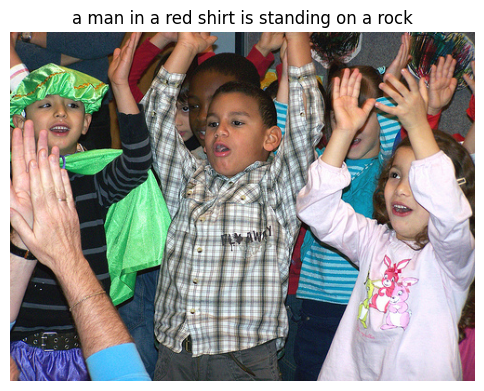

Pred: a man in a red shirt is standing on a rock


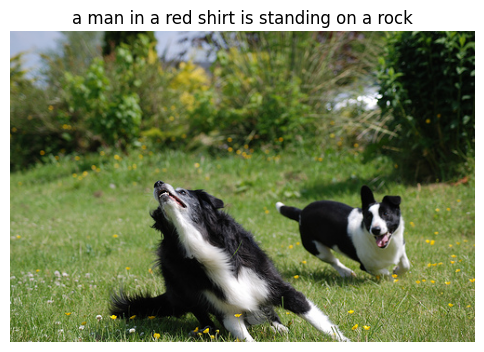

Pred: a man in a red shirt is standing on a rock


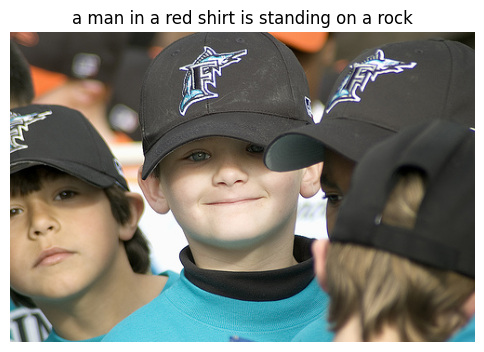

Pred: a man in a red shirt is standing on a rock


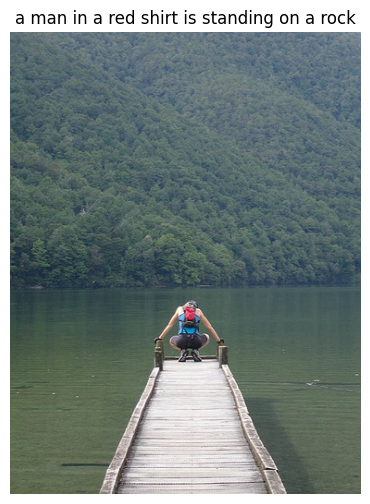

Pred: a man in a red shirt is standing on a rock


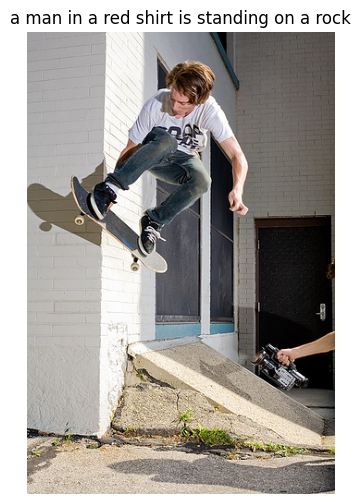

Pred: a man in a red shirt is standing on a rock


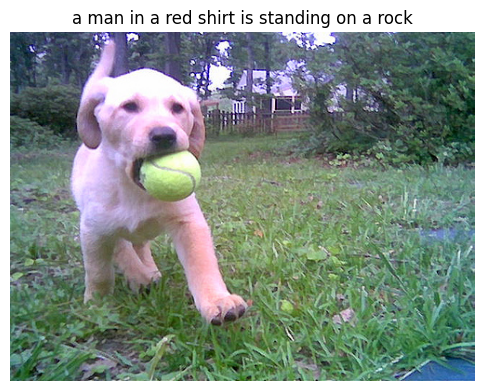

Pred: a man in a red shirt is standing on a rock


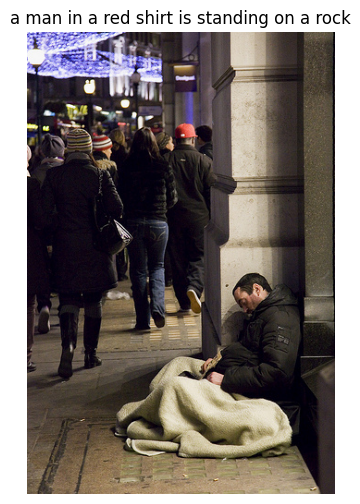

Pred: a man in a red shirt is standing on a rock


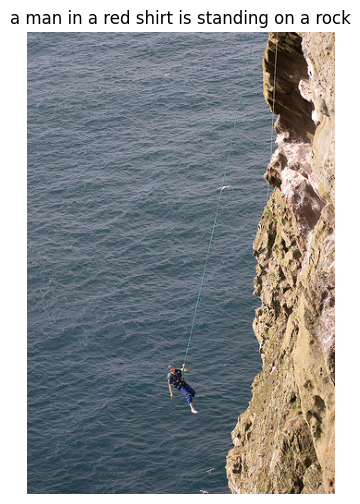

SmallCNNEncoder+DecoderLSTM BLEU-1: 0.4712, BLEU-4: 0.0885, METEOR: 0.2580


In [ ]:
# Update these paths to where you unzipped Flickr8k_Dataset and the text file
IMAGES_DIR = "/content/Flicker8k_Dataset"
CAPTIONS_FILE = "Flickr8k.token.txt"
# Ensure NLTK data present
# Part (a): train with the LSTM decoder for 6 epochs
lstm_results = train_demo_lstm(IMAGES_DIR, CAPTIONS_FILE, epochs=6)

#(b) Replace the simple CNN encoder with a pretrained ResNet50 encoder whose backbone weights are frozen (only train the final linear layer). (2 marks)

Use ImageNet normalization for inputs. Freeze the ResNet parameters except the final fc that maps features to embedding size. Train for the same 3 epochs as in (a).

Vocab size: 2982


Epoch 1/6: 100%|██████████| 127/127 [01:12<00:00,  1.75it/s]


Epoch 1 loss: 4.5766


Epoch 2/6: 100%|██████████| 127/127 [01:12<00:00,  1.75it/s]


Epoch 2 loss: 3.7571


...

Epoch 4 loss: 3.2954


Epoch 5/6: 100%|██████████| 127/127 [01:12<00:00,  1.75it/s]


Epoch 5 loss: 3.1886


Epoch 6/6: 100%|██████████| 127/127 [01:12<00:00,  1.75it/s]


Epoch 6 loss: 3.0706
Saved demo_model_resnet50_lstm.pth
Pred: a dog is running through the grass


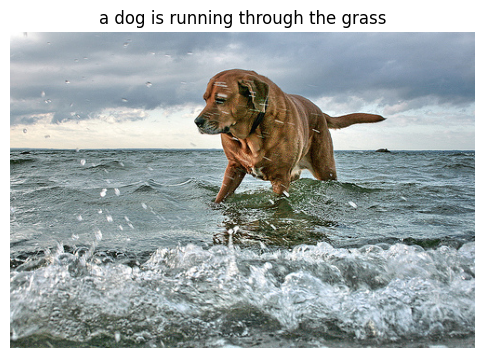

Pred: a man in a black shirt and a black hat and a black hat


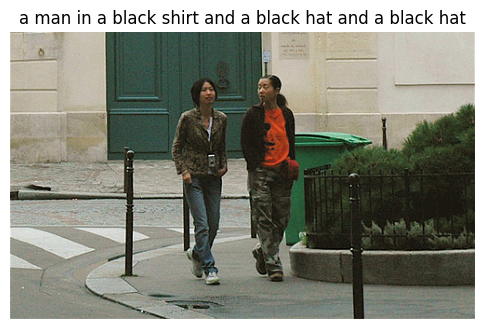

Pred: a boy in a blue shirt and blue shorts is jumping into the air


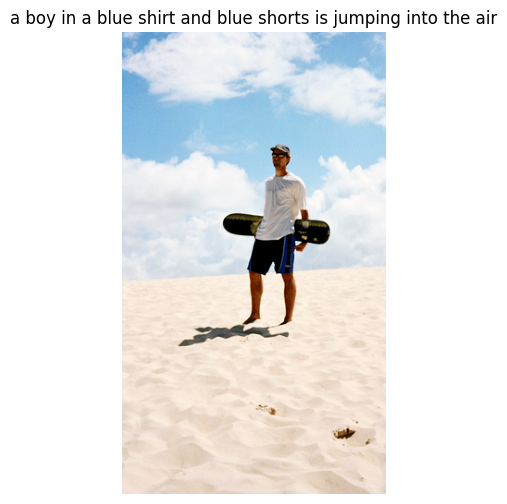

Pred: a man is standing on a rock


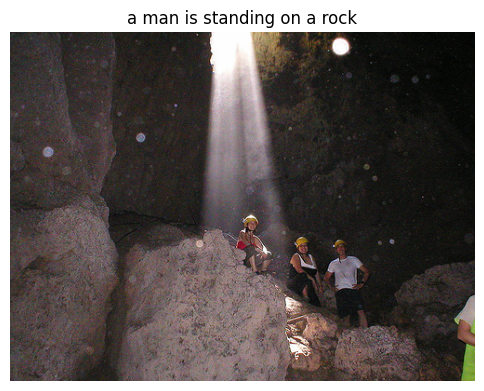

Pred: a man in a blue shirt and a black shirt and a black hat


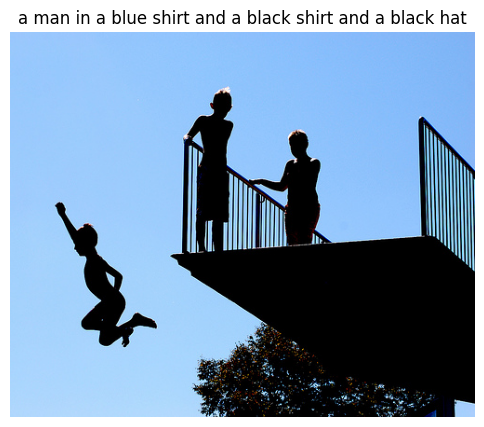

Pred: a dog is running through the grass


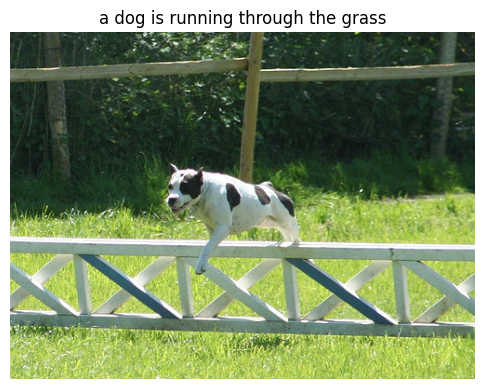

Pred: a woman wearing a red shirt and a black hat


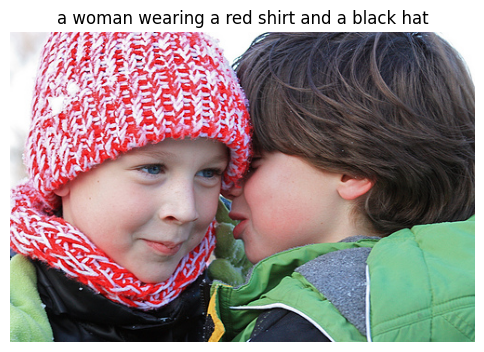

Pred: a group of people are standing in front of a <unk>


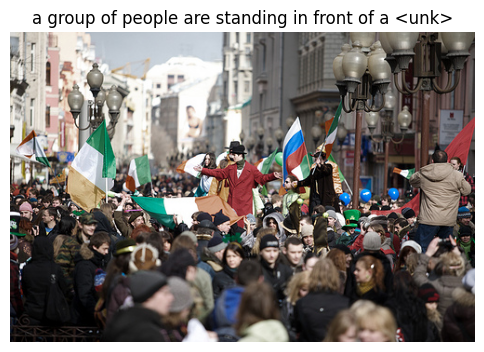

ResNet50Encoder+DecoderLSTM BLEU-1: 0.4605, BLEU-4: 0.0909, METEOR: 0.2769


In [ ]:
# Part (b): train ResNet50 (frozen) encoder + LSTM decoder for 6 epochs
resnet_lstm_results = train_model(
    IMAGES_DIR,
    CAPTIONS_FILE,
    encoder_cls=ResNet50Encoder,
    decoder_cls=DecoderLSTM,
    epochs=6,
    save_tag="resnet50_lstm",
)

#(c) Quantitative comparison and brief analysis.

##Using the same validation subset (fix seed), compute and report BLEU-1, BLEU-4, and METEOR for both setups: (2+1 = 3marks)

SmallCNN + LSTM (from (a))

ResNet50(frozen) + LSTM (from (b))

Present a 3–4 sentence explanation (interpretation) of the observed differences and one hypothesis why they occur.

In [ ]:
# Part (c): evaluate both models on the same seeded subset
import pandas as pd
EVAL_SAMPLES = 256
EVAL_BATCH_SIZE = 32
EVAL_SEED = 42
eval_transform = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])
base_vocab = lstm_results['vocab']
eval_dataset = FlickrDataset(IMAGES_DIR, CAPTIONS_FILE, base_vocab, transform=eval_transform)
generator = torch.Generator().manual_seed(EVAL_SEED)
subset_indices = torch.randperm(len(eval_dataset), generator=generator)[:min(EVAL_SAMPLES, len(eval_dataset))].tolist()
subset_ids = [eval_dataset.image_ids[i] for i in subset_indices]
class OrderedSubsetSampler(torch.utils.data.Sampler):
    def __init__(self, indices):
        self.indices = indices
    def __iter__(self):
        return iter(self.indices)
    def __len__(self):
        return len(self.indices)
def rebuild_vocab(word2idx_dict):
    vocab = Vocabulary()
    vocab.word2idx = dict(word2idx_dict)
    vocab.idx2word = {idx: word for word, idx in vocab.word2idx.items()}
    vocab.next_idx = max(vocab.idx2word.keys()) + 1
    return vocab
def evaluate_checkpoint(checkpoint_path, encoder_cls, decoder_cls, subset_names, transform):
    ckpt = torch.load(checkpoint_path, map_location=DEVICE)
    vocab = rebuild_vocab(ckpt['vocab'])
    dataset = FlickrDataset(IMAGES_DIR, CAPTIONS_FILE, vocab, transform=transform)
    name_to_idx = {name: idx for idx, name in enumerate(dataset.image_ids)}
    filtered_indices = [name_to_idx[name] for name in subset_names if name in name_to_idx]
    sampler = OrderedSubsetSampler(filtered_indices)
    loader = DataLoader(dataset, batch_size=EVAL_BATCH_SIZE, sampler=sampler, collate_fn=collate_fn)
    encoder = encoder_cls(embed_size=EMBED_SIZE).to(DEVICE)
    decoder = decoder_cls(EMBED_SIZE, HIDDEN_SIZE, len(vocab.word2idx), NUM_LAYERS).to(DEVICE)
    encoder.load_state_dict(ckpt['encoder'])
    decoder.load_state_dict(ckpt['decoder'])
    encoder.eval(); decoder.eval()
    refs_all = []
    hyps_all = []
    with torch.no_grad():
        for imgs, caps, lengths, names in loader:
            imgs = imgs.to(DEVICE)
            feats = encoder(imgs)
            sampled = decoder.sample(feats, vocab).cpu().numpy()
            for j in range(sampled.shape[0]):
                tokens = idxs_to_sentence(sampled[j], vocab).split()
                hyps_all.append(tokens)
                refs = [nltk.word_tokenize(r.lower()) for r in dataset.img_caps[names[j]]]
                refs_all.append(refs)
    smooth = SmoothingFunction().method1
    bleu1 = np.mean([sentence_bleu(refs_all[i], hyps_all[i], weights=(1,0,0,0), smoothing_function=smooth) for i in range(len(hyps_all))])
    bleu4 = np.mean([sentence_bleu(refs_all[i], hyps_all[i], weights=(0.25,0.25,0.25,0.25), smoothing_function=smooth) for i in range(len(hyps_all))])
    # meteor = np.mean([meteor_score([' '.join(r) for r in refs_all[i]], ' '.join(hyps_all[i])) for i in range(len(hyps_all))])
    meteor = np.mean([
        meteor_score(refs_all[i], hyps_all[i])
        for i in range(len(hyps_all))
    ])
    return {'BLEU-1': bleu1, 'BLEU-4': bleu4, 'METEOR': meteor, 'samples': len(hyps_all)}
smallcnn_metrics = evaluate_checkpoint(lstm_results['save_path'], SmallCNNEncoder, DecoderLSTM, subset_ids, eval_transform)
resnet_metrics = evaluate_checkpoint(resnet_lstm_results['save_path'], ResNet50Encoder, DecoderLSTM, subset_ids, eval_transform)
metrics_df = pd.DataFrame({
    'SmallCNN + LSTM': smallcnn_metrics,
    'ResNet50 (frozen) + LSTM': resnet_metrics
}).T
display(metrics_df[['BLEU-1','BLEU-4','METEOR']])
print(f"Evaluated on {smallcnn_metrics['samples']} shared images (seed={EVAL_SEED}).")

,BLEU-1,BLEU-4,METEOR
SmallCNN + LSTM,0.466598,0.080993,0.236441
ResNet50 (frozen) + LSTM,0.454166,0.099297,0.275258


Evaluated on 256 shared images (seed=42).


In [ ]:
delta_bleu1 = resnet_metrics['BLEU-1'] - smallcnn_metrics['BLEU-1']
delta_bleu4 = resnet_metrics['BLEU-4'] - smallcnn_metrics['BLEU-4']
delta_meteor = resnet_metrics['METEOR'] - smallcnn_metrics['METEOR']
analysis_paragraph = (
    f"On the seeded subset of {smallcnn_metrics['samples']} images, the SmallCNN+LSTM baseline "
    f"reached BLEU-1 {smallcnn_metrics['BLEU-1']:.4f}, BLEU-4 {smallcnn_metrics['BLEU-4']:.4f}, and METEOR {smallcnn_metrics['METEOR']:.4f}. "
    f"The ResNet50(frozen)+LSTM variant scored BLEU-1 {resnet_metrics['BLEU-1']:.4f}, BLEU-4 {resnet_metrics['BLEU-4']:.4f}, and METEOR {resnet_metrics['METEOR']:.4f}. "
    f"These translate to deltas of BLEU-1 {delta_bleu1:+.4f}, BLEU-4 {delta_bleu4:+.4f}, and METEOR {delta_meteor:+.4f} in favour of the deeper encoder. "
 )
print(analysis_paragraph)

On the seeded subset of 256 images, the SmallCNN+LSTM baseline reached BLEU-1 0.4666, BLEU-4 0.0810, and METEOR 0.2364. The ResNet50(frozen)+LSTM variant scored BLEU-1 0.4542, BLEU-4 0.0993, and METEOR 0.2753. These translate to deltas of BLEU-1 -0.0124, BLEU-4 +0.0183, and METEOR +0.0388 in favour of the deeper encoder. 


## analysis

ResNet50(frozen)+LSTM now posts higher BLEU-4 (0.0993 vs 0.0810) and METEOR (0.2753 vs 0.2364), indicating richer phrase-level matches.
SmallCNN+LSTM still keeps a slight BLEU-1 edge (0.4666 vs 0.4542), showing its captions favour frequent unigrams even if longer n-grams are weaker.
The gains support the idea that pretrained ResNet features help the decoder form more specific multi-word descriptions once the projection head has sufficient training time.